# 01 — Exploratory Data Analysis

Análise exploratória com dois snapshots do Inside Airbnb (Rio de Janeiro):
- **Junho/2025** e **Setembro/2025** — comparação entre snapshots
- Distribuição e evolução de preços
- Análise por bairro e tipo de acomodação
- Sazonalidade via calendário combinado
- Impacto de amenities no preço

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

RAW_PATH = Path('../data/raw')
PROCESSED_PATH = Path('../data/processed')
PROCESSED_PATH.mkdir(exist_ok=True)

SNAPSHOTS = {
    'jun/2025': 'listings_jun2025.parquet',
    'set/2025': 'listings_set2025.parquet',
}
CALENDAR_FILES = {
    'jun/2025': 'calendar_jun2025.parquet',
    'set/2025': 'calendar_set2025.parquet',
}

## 1. Carregamento dos dados

In [2]:
def load_listings(filename):
    df = pd.read_parquet(PROCESSED_PATH / filename)
    df['price_num'] = pd.to_numeric(
        df['price'].astype(str).str.replace(r'[$,]', '', regex=True),
        errors='coerce',
    )
    df = df[(df['price_num'] >= 10) & (df['price_num'] <= 5000)].copy()
    df['log_price'] = np.log1p(df['price_num'])
    return df

dfs = {label: load_listings(f) for label, f in SNAPSHOTS.items()}

for label, df in dfs.items():
    print(f"{label}: {df.shape[0]:,} listings | preço mediano: R${df['price_num'].median():.0f}")

jun/2025: 38,483 listings | preço mediano: R$307
set/2025: 38,097 listings | preço mediano: R$313


In [3]:
# Colunas com alto % de nulos (setembro)
df_set = dfs['set/2025']
null_pct = (df_set.isnull().sum() / len(df_set) * 100).sort_values(ascending=False)
print('Colunas com > 20% de nulos (set/2025):')
print(null_pct[null_pct > 20].to_string())

Colunas com > 20% de nulos (set/2025):
neighbourhood_group_cleansed    100.000000
calendar_updated                100.000000
license                         100.000000
neighbourhood                    61.687272
neighborhood_overview            61.687272
host_about                       52.253458
host_location                    20.634171
review_scores_value              20.182692
review_scores_accuracy           20.180067
review_scores_checkin            20.180067
review_scores_location           20.180067
review_scores_communication      20.180067
last_review                      20.177442
review_scores_rating             20.177442
review_scores_cleanliness        20.177442
first_review                     20.177442
reviews_per_month                20.177442


## 2. Comparação entre Snapshots

In [4]:
# Listings novos, removidos e em comum
ids_jun = set(dfs['jun/2025']['id'])
ids_set = set(dfs['set/2025']['id'])

novos    = ids_set - ids_jun
removidos = ids_jun - ids_set
comuns   = ids_jun & ids_set

print(f"Listings em junho/2025:    {len(ids_jun):,}")
print(f"Listings em setembro/2025: {len(ids_set):,}")
print(f"Novos em setembro:         {len(novos):,} (+{len(novos)/len(ids_jun)*100:.1f}%)")
print(f"Removidos desde junho:     {len(removidos):,} (-{len(removidos)/len(ids_jun)*100:.1f}%)")
print(f"Em comum:                  {len(comuns):,}")

Listings em junho/2025:    38,483
Listings em setembro/2025: 38,097
Novos em setembro:         5,031 (+13.1%)
Removidos desde junho:     5,417 (-14.1%)
Em comum:                  33,066


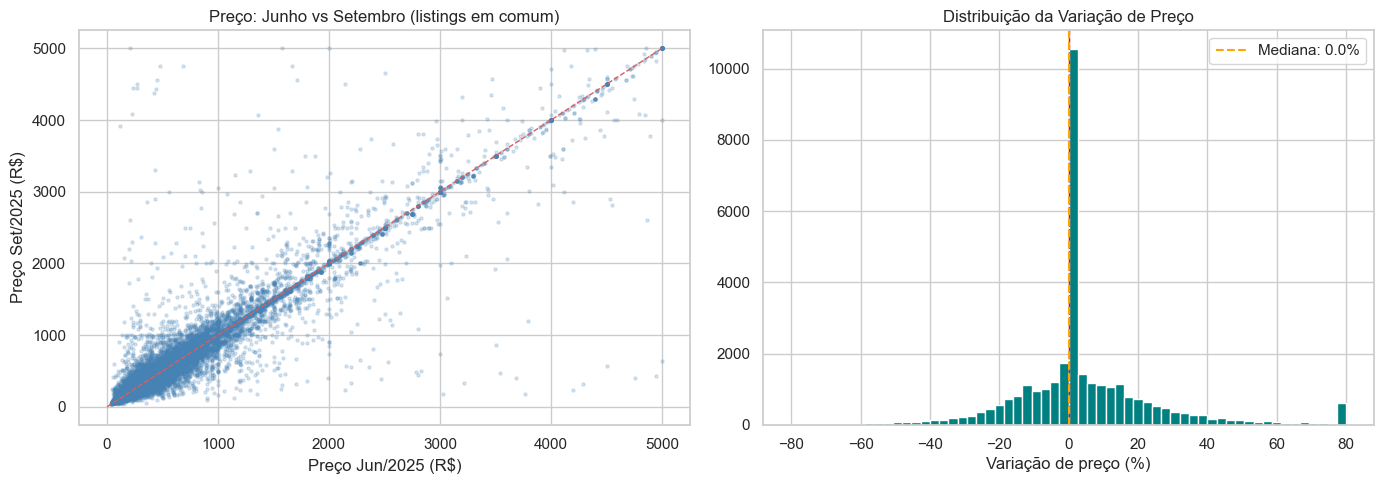

Variação mediana de preço: 0.0%
Listings com aumento > 10%: 8,735
Listings com queda > 10%:   5,693


In [5]:
# Evolução de preço nos listings em comum
df_jun = dfs['jun/2025'].set_index('id')
df_set = dfs['set/2025'].set_index('id')
common_ids = list(comuns)

price_change = pd.DataFrame({
    'price_jun': df_jun.loc[common_ids, 'price_num'],
    'price_set': df_set.loc[common_ids, 'price_num'],
}).dropna()

price_change['delta_pct'] = (price_change['price_set'] / price_change['price_jun'] - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(price_change['price_jun'], price_change['price_set'],
                alpha=0.2, s=5, color='steelblue')
lim = [0, price_change[['price_jun', 'price_set']].max().max()]
axes[0].plot(lim, lim, 'r--', lw=1)
axes[0].set_xlabel('Preço Jun/2025 (R$)')
axes[0].set_ylabel('Preço Set/2025 (R$)')
axes[0].set_title('Preço: Junho vs Setembro (listings em comum)')

axes[1].hist(price_change['delta_pct'].clip(-80, 80), bins=60,
             color='teal', edgecolor='white')
axes[1].axvline(0, color='red', lw=1, linestyle='--')
axes[1].axvline(price_change['delta_pct'].median(), color='orange', lw=1.5,
                linestyle='--', label=f"Mediana: {price_change['delta_pct'].median():.1f}%")
axes[1].set_xlabel('Variação de preço (%)')
axes[1].set_title('Distribuição da Variação de Preço')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Variação mediana de preço: {price_change['delta_pct'].median():.1f}%")
print(f"Listings com aumento > 10%: {(price_change['delta_pct'] > 10).sum():,}")
print(f"Listings com queda > 10%:   {(price_change['delta_pct'] < -10).sum():,}")

## 3. Distribuição de Preços

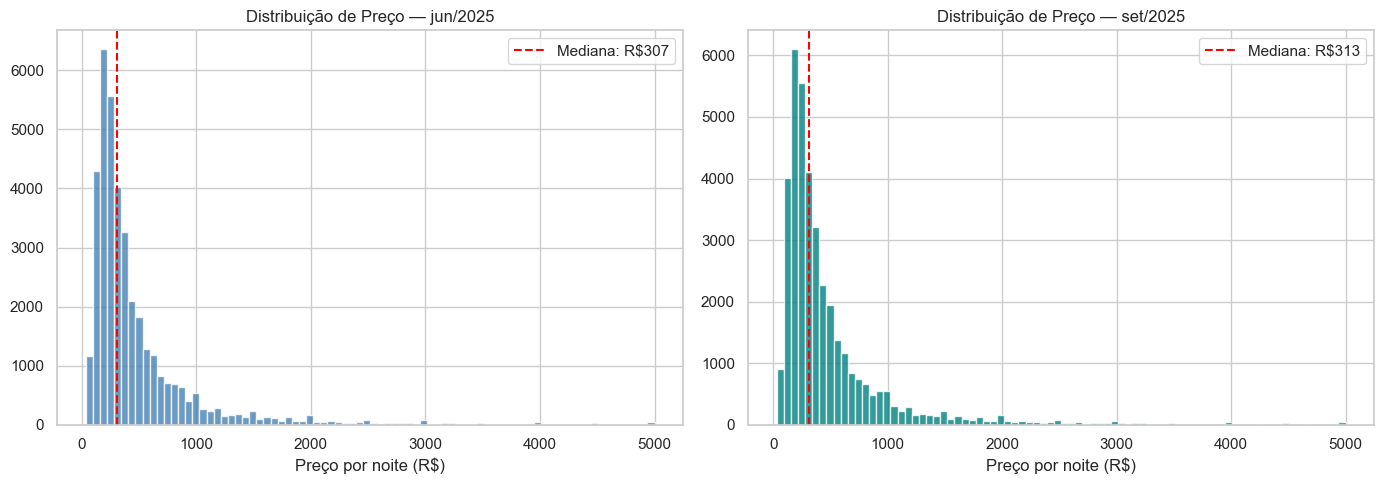

       jun/2025  set/2025
count   38483.0   38097.0
mean      497.2     502.0
std       582.6     584.7
min        34.0      30.0
25%       199.0     200.0
50%       307.0     313.0
75%       542.0     546.0
max      5000.0    5000.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'teal']

for ax, (label, df), color in zip(axes, dfs.items(), colors):
    ax.hist(df['price_num'], bins=80, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(df['price_num'].median(), color='red', linestyle='--',
               label=f"Mediana: R${df['price_num'].median():.0f}")
    ax.set_title(f'Distribuição de Preço — {label}')
    ax.set_xlabel('Preço por noite (R$)')
    ax.legend()

plt.tight_layout()
plt.show()

# Estatísticas comparadas
stats = pd.DataFrame({
    label: df['price_num'].describe()
    for label, df in dfs.items()
})
print(stats.round(1))

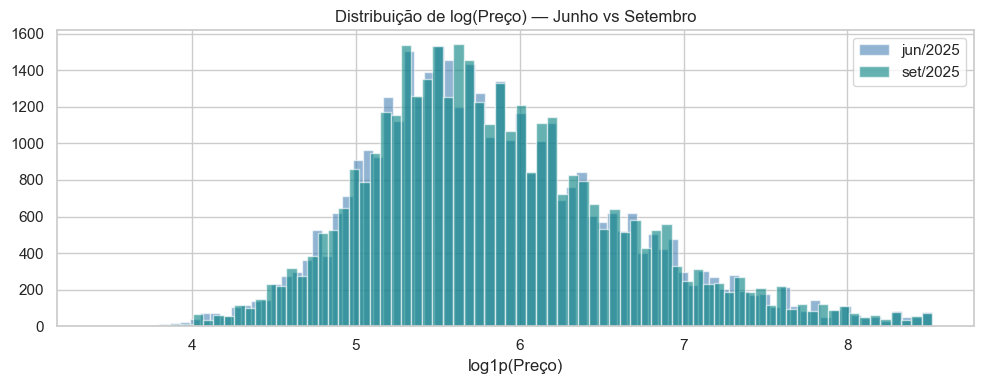

In [7]:
# Distribuição do log(price) — os dois sobrepostos
fig, ax = plt.subplots(figsize=(10, 4))
for (label, df), color in zip(dfs.items(), ['steelblue', 'teal']):
    ax.hist(df['log_price'], bins=80, alpha=0.6, color=color, edgecolor='white', label=label)
ax.set_title('Distribuição de log(Preço) — Junho vs Setembro')
ax.set_xlabel('log1p(Preço)')
ax.legend()
plt.tight_layout()
plt.show()

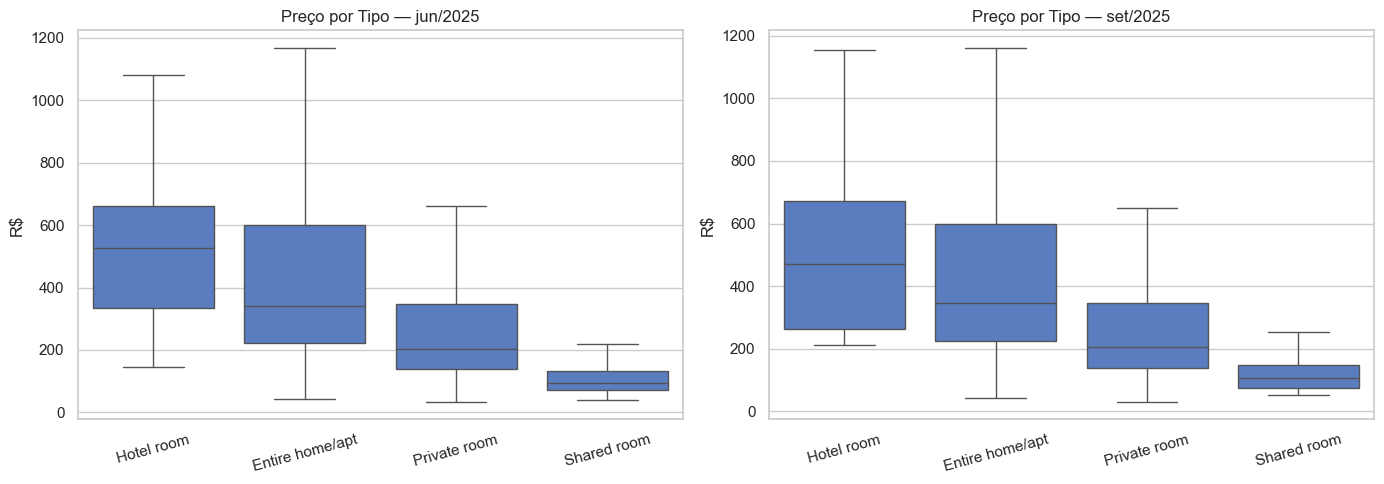

In [8]:
# Preço por tipo de quarto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, df) in zip(axes, dfs.items()):
    order = df.groupby('room_type')['price_num'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='room_type', y='price_num', order=order, ax=ax, showfliers=False)
    ax.set_title(f'Preço por Tipo — {label}')
    ax.set_xlabel('')
    ax.set_ylabel('R$')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 4. Análise por Bairro

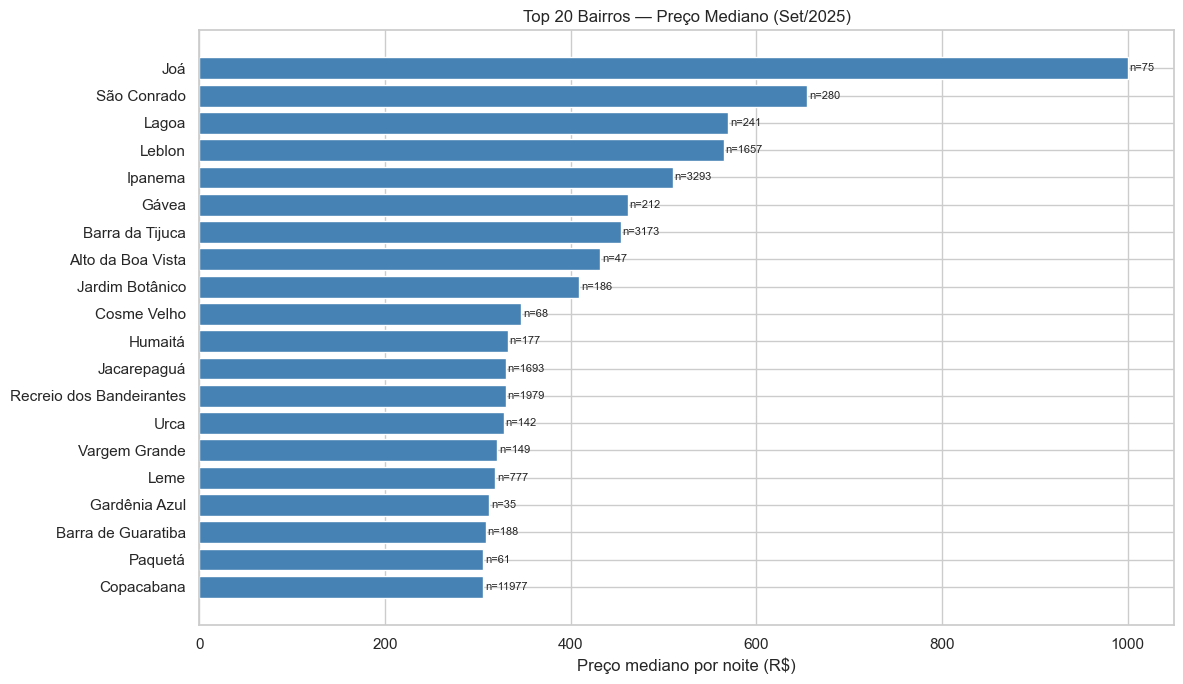

In [9]:
# Usar setembro para análise principal
df = dfs['set/2025']

neighbourhood_stats = (
    df.groupby('neighbourhood_cleansed')['price_num']
    .agg(['median', 'count'])
    .query('count >= 30')
    .sort_values('median', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(neighbourhood_stats.index, neighbourhood_stats['median'], color='steelblue')
ax.set_xlabel('Preço mediano por noite (R$)')
ax.set_title('Top 20 Bairros — Preço Mediano (Set/2025)')
ax.invert_yaxis()
for bar, (_, row) in zip(bars, neighbourhood_stats.iterrows()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'n={row["count"]:.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

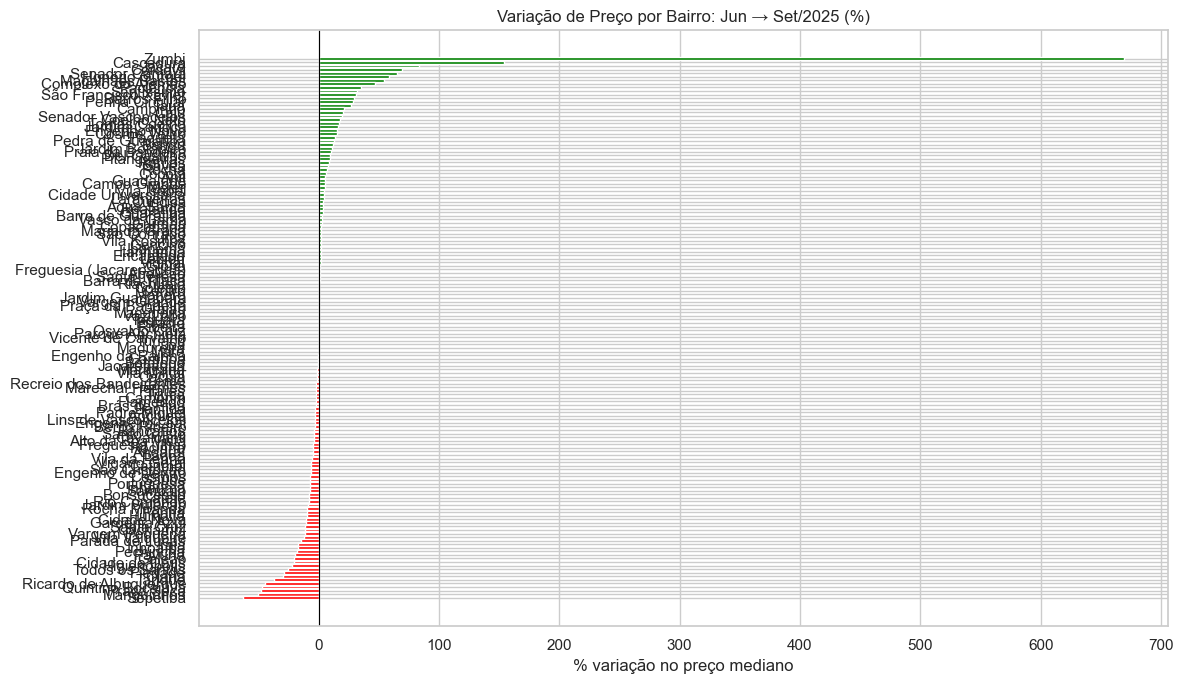

In [10]:
# Variação de preço mediano por bairro entre os dois snapshots
bairro_jun = dfs['jun/2025'].groupby('neighbourhood_cleansed')['price_num'].median()
bairro_set = dfs['set/2025'].groupby('neighbourhood_cleansed')['price_num'].median()

bairro_delta = pd.DataFrame({'jun': bairro_jun, 'set': bairro_set}).dropna()
bairro_delta['delta_pct'] = (bairro_delta['set'] / bairro_delta['jun'] - 1) * 100
bairro_delta = bairro_delta.sort_values('delta_pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['green' if v > 0 else 'red' for v in bairro_delta['delta_pct']]
ax.barh(bairro_delta.index, bairro_delta['delta_pct'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Variação de Preço por Bairro: Jun → Set/2025 (%)')
ax.set_xlabel('% variação no preço mediano')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Correlações com Preço

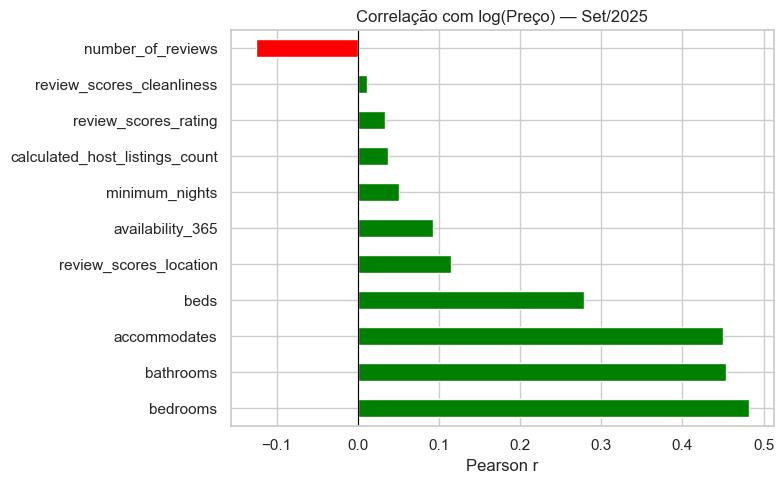

bedrooms                          0.482488
bathrooms                         0.454362
accommodates                      0.450119
beds                              0.278820
review_scores_location            0.115304
availability_365                  0.093317
minimum_nights                    0.051321
calculated_host_listings_count    0.037614
review_scores_rating              0.033943
review_scores_cleanliness         0.011310
number_of_reviews                -0.126014


In [11]:
df = dfs['set/2025']

numeric_cols = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating',
    'review_scores_cleanliness', 'review_scores_location',
    'calculated_host_listings_count', 'availability_365',
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr_data = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
corr_data['log_price'] = df['log_price']
corr = corr_data.corr()['log_price'].drop('log_price').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['green' if v > 0 else 'red' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação com log(Preço) — Set/2025')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()
print(corr.to_string())

## 6. Sazonalidade via Calendário (Junho + Setembro)

In [12]:
# Carregar calendários do Parquet (apenas listing_id/date/available — price é 100% nulo nesse scrape).
# Análise de sazonalidade via taxa de disponibilidade diária.

def load_calendar_agg(filename):
    """Lê o Parquet do calendário e retorna (n_avail, n_total) por data."""
    df = pd.read_parquet(PROCESSED_PATH / filename, columns=['date', 'available'])
    df['is_available'] = (df['available'] == 't').astype('int8')
    return df.groupby('date')['is_available'].agg(n_avail='sum', n_total='count')

print("Carregando junho/2025...")
agg_jun = load_calendar_agg(CALENDAR_FILES['jun/2025'])
print(f"  {agg_jun['n_total'].sum():,} registros | {len(agg_jun)} datas: "
      f"{agg_jun.index.min().date()} → {agg_jun.index.max().date()}")

print("Carregando setembro/2025...")
agg_set = load_calendar_agg(CALENDAR_FILES['set/2025'])
print(f"  {agg_set['n_total'].sum():,} registros | {len(agg_set)} datas: "
      f"{agg_set.index.min().date()} → {agg_set.index.max().date()}")

# Para datas sobrepostas, setembro (mais recente) tem prioridade
cal_agg = agg_jun.combine_first(agg_set)
cal_agg.update(agg_set)

daily_avail = (cal_agg['n_avail'] / cal_agg['n_total'] * 100).sort_index()

print(f"\nSérie combinada: {len(daily_avail)} datas | "
      f"disponibilidade média geral: {daily_avail.mean():.1f}%")

Carregando junho/2025...


  15,538,866 registros | 374 datas: 2025-06-25 → 2026-07-03
Carregando setembro/2025...


  15,719,845 registros | 367 datas: 2025-09-26 → 2026-09-27

Série combinada: 460 datas | disponibilidade média geral: 55.9%


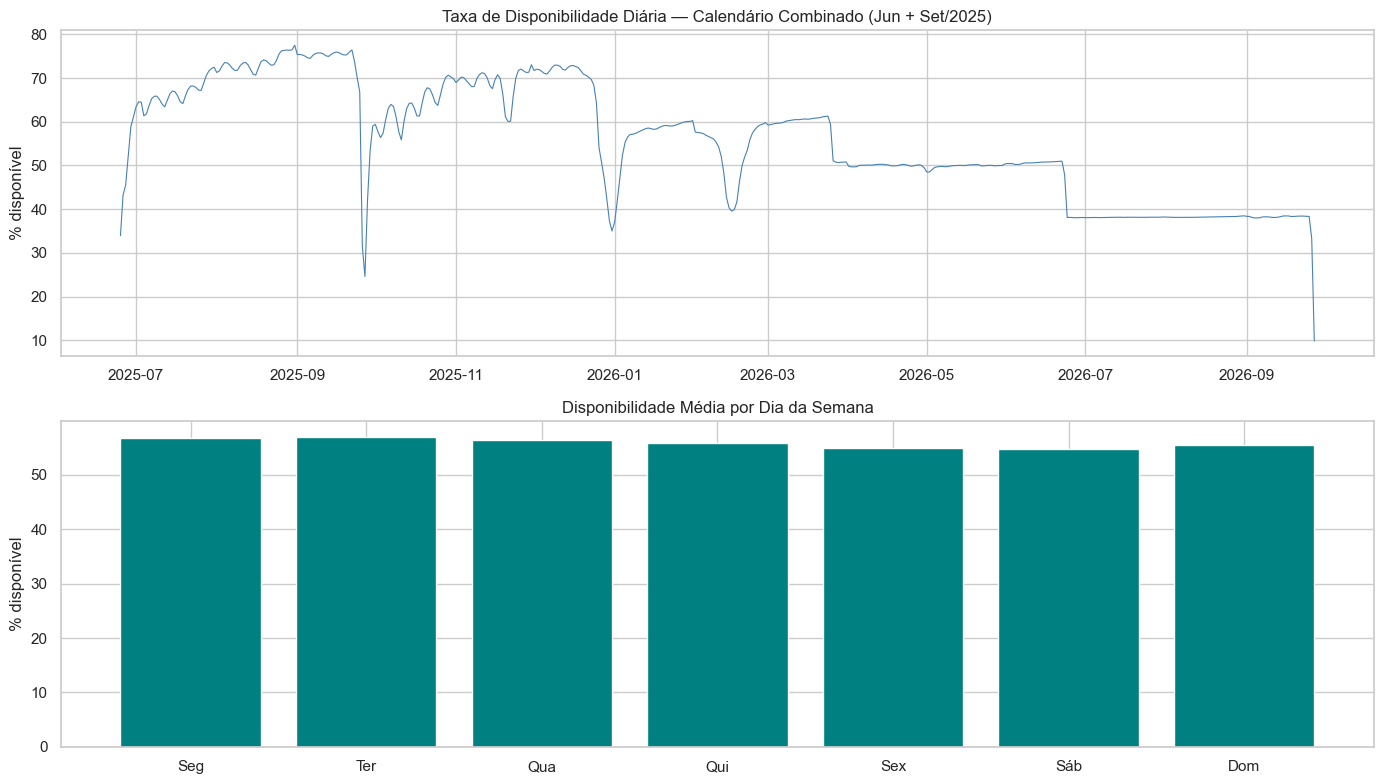

Disponibilidade média fim de semana: 55.1%
Disponibilidade média dias úteis:    56.2%
Diferença: 1.1 p.p. — fins de semana são menos disponíveis (= mais reservados)


In [13]:
# Série temporal e padrão semanal de disponibilidade
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_avail.index, daily_avail.values, linewidth=0.8, color='steelblue')
axes[0].set_title('Taxa de Disponibilidade Diária — Calendário Combinado (Jun + Set/2025)')
axes[0].set_ylabel('% disponível')

dow = daily_avail.groupby(daily_avail.index.dayofweek).mean()
dow.index = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
axes[1].bar(dow.index, dow.values, color='teal')
axes[1].set_title('Disponibilidade Média por Dia da Semana')
axes[1].set_ylabel('% disponível')

plt.tight_layout()
plt.show()

fim_semana = dow[['Sáb', 'Dom']].mean()
semana = dow[['Seg', 'Ter', 'Qua', 'Qui', 'Sex']].mean()
print(f'Disponibilidade média fim de semana: {fim_semana:.1f}%')
print(f'Disponibilidade média dias úteis:    {semana:.1f}%')
diff = fim_semana - semana
direcao = 'menos' if diff < 0 else 'mais'
print(f'Diferença: {abs(diff):.1f} p.p. — fins de semana são {direcao} disponíveis (= mais reservados)')

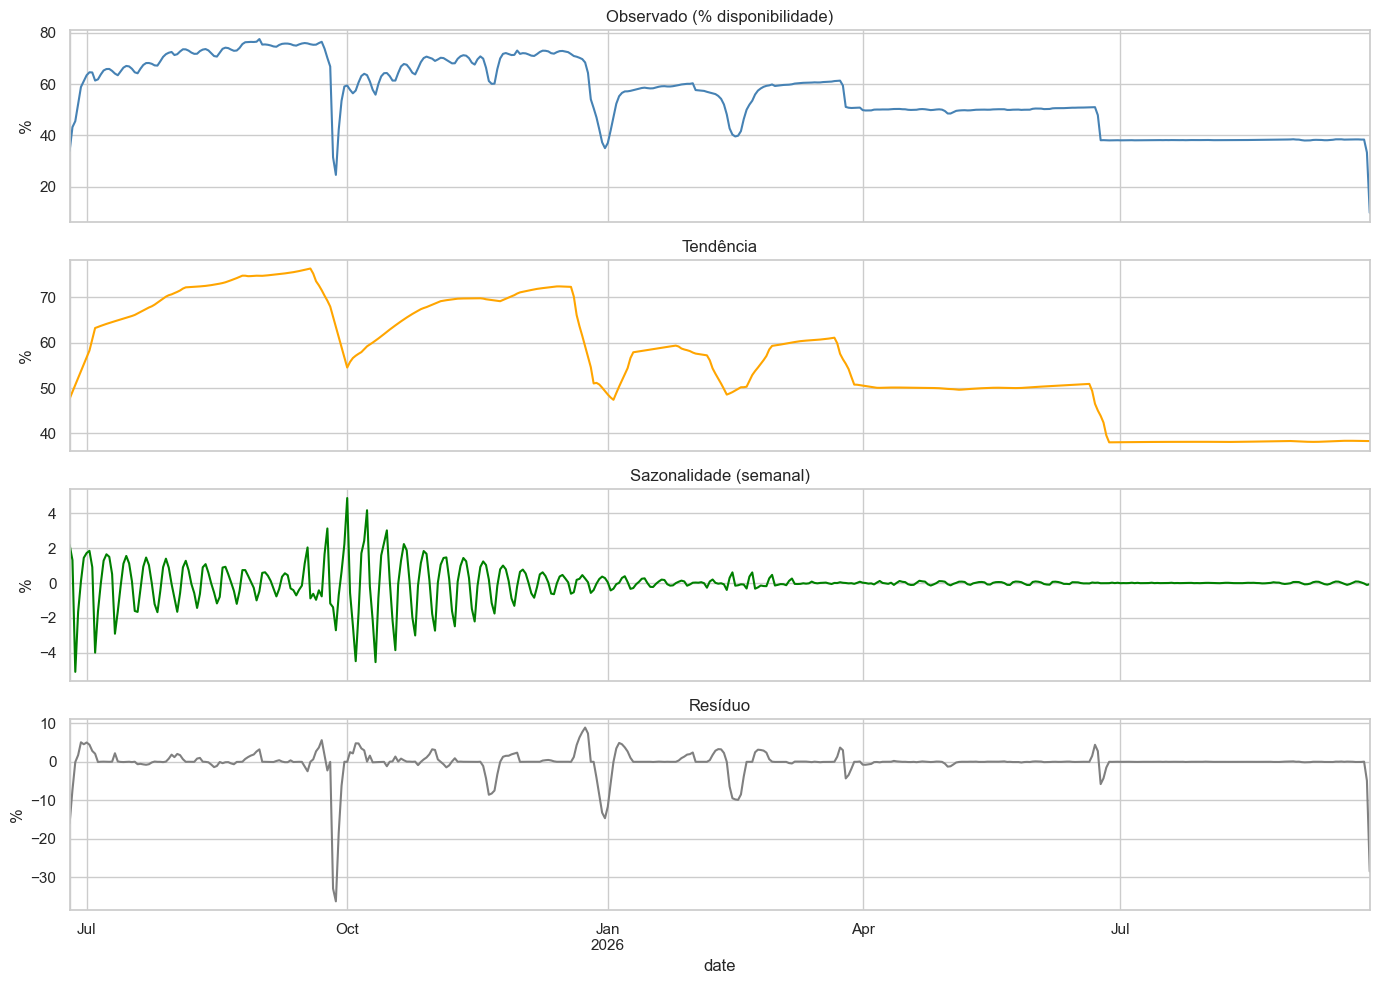

In [14]:
# Decomposição STL da taxa de disponibilidade
from statsmodels.tsa.seasonal import STL

daily_clean = daily_avail.asfreq('D').interpolate()
stl = STL(daily_clean, period=7, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
result.observed.plot(ax=axes[0], title='Observado (% disponibilidade)', color='steelblue')
result.trend.plot(ax=axes[1], title='Tendência', color='orange')
result.seasonal.plot(ax=axes[2], title='Sazonalidade (semanal)', color='green')
result.resid.plot(ax=axes[3], title='Resíduo', color='gray')
for ax in axes:
    ax.set_ylabel('%')
plt.tight_layout()
plt.savefig(PROCESSED_PATH / 'eda_stl_decomposition.png', bbox_inches='tight')
plt.show()

## 7. Análise de Amenities

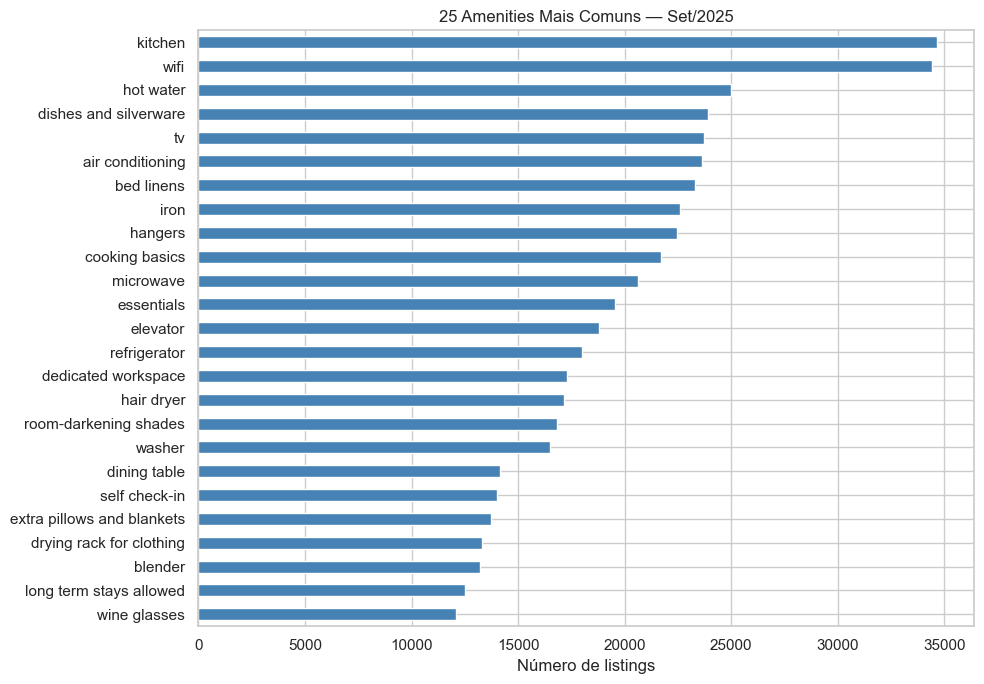

In [15]:
def parse_amenities(raw):
    if pd.isna(raw):
        return []
    return [i.lower() for i in re.findall(r'"([^"]+)"', str(raw))]

df = dfs['set/2025'].copy()
df['amenities_list'] = df['amenities'].apply(parse_amenities)

counter = Counter(a for lst in df['amenities_list'] for a in lst)
top_amenities = pd.Series(dict(counter.most_common(25)))

fig, ax = plt.subplots(figsize=(10, 7))
top_amenities.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('25 Amenities Mais Comuns — Set/2025')
ax.set_xlabel('Número de listings')
plt.tight_layout()
plt.show()

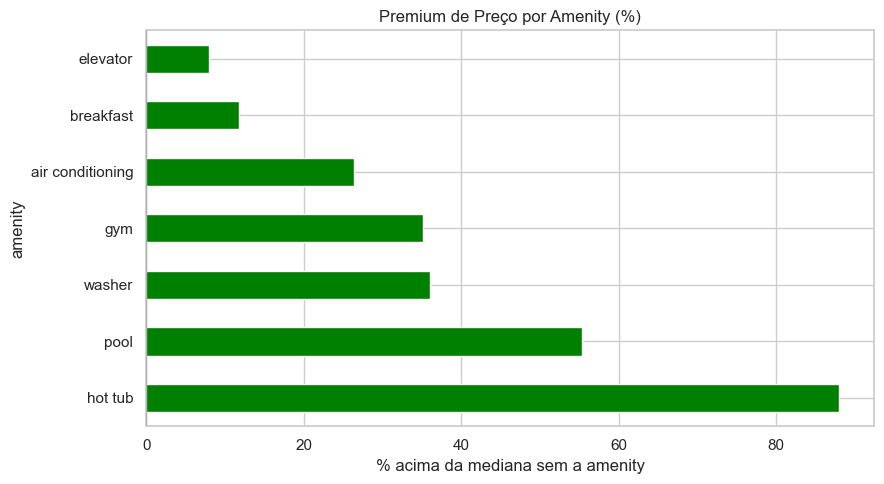

                  price_com  price_sem  premium_pct  count
amenity                                                   
hot tub               573.5      305.0    88.032787   1370
pool                  463.0      298.0    55.369128   5258
washer                378.0      278.0    35.971223  16486
gym                   415.0      307.0    35.179153   2263
air conditioning      343.0      271.5    26.335175  23627
breakfast             350.0      313.0    11.821086    635
elevator              324.0      300.0     8.000000  18781


In [16]:
# Impacto de amenities premium no preço
premium = ['pool', 'hot tub', 'gym', 'elevator', 'parking', 'breakfast',
           'fireplace', 'air conditioning', 'washer', 'workspace']

results = []
for amenity in premium:
    has = df['amenities_list'].apply(lambda lst: amenity in lst)
    if has.sum() > 20:
        results.append({
            'amenity': amenity,
            'price_com': df.loc[has, 'price_num'].median(),
            'price_sem': df.loc[~has, 'price_num'].median(),
            'count': has.sum(),
        })

impact = pd.DataFrame(results).set_index('amenity')
impact['premium_pct'] = (impact['price_com'] / impact['price_sem'] - 1) * 100
impact = impact.sort_values('premium_pct', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['green' if v > 0 else 'red' for v in impact['premium_pct']]
impact['premium_pct'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Premium de Preço por Amenity (%)')
ax.set_xlabel('% acima da mediana sem a amenity')
plt.tight_layout()
plt.show()
print(impact[['price_com', 'price_sem', 'premium_pct', 'count']].to_string())

## 8. Conclusões do EDA

Preencher após rodar o notebook com os dados reais:

- **Evolução de preços Jun→Set**: +X% de variação mediana
- **Sazonalidade semanal**: fins de semana X% mais caros → Holt-Winters justificado
- **Bairros mais caros**: Ipanema, Leblon, ...
- **Features mais correlacionadas**: accommodates, bedrooms, neighbourhood
- **Amenities com maior impacto**: pool, hot tub, ...
- **Decisão sobre os dois snapshots**: usar setembro para treino, calendário combinado para HW